In [ ]:
import logging
from kiteconnect import KiteConnect
import datetime
logging.basicConfig(level=logging.INFO)
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import pyotp
import requests

import environ
env = environ.Env()

In [ ]:
# Secrets
USER_ID = env('USER_ID')
PASSWORD = env('PASSWORD')
API_KEY = env('API_KEY')
API_SECRET = env('API_SECRET')
TOTP_SECRET = env('TOTP_SECRET')
kite = KiteConnect(api_key=API_KEY)
totp = pyotp.TOTP(TOTP_SECRET)

In [3]:
def get_request_token(user_id: str, password: str, kite: KiteConnect, totp: pyotp.TOTP) -> str:
    headers = {"Content-Type": "application/x-www-form-urlencoded"}

    with requests.Session() as session:
        # 1) post credentials
        login_payload = {"user_id": user_id, "password": password, "type": "user_id"}
        login_resp = session.post("https://kite.zerodha.com/api/login", data=login_payload, headers=headers).json()

        # 2) post TOTP
        totp_payload = {
            "user_id": user_id,
            "request_id": login_resp["data"]["request_id"],
            "twofa_type": "totp",
            "skip_session": True,
            "twofa_value": f"{totp.now()}",
        }
        session.post("https://kite.zerodha.com/api/twofa", data=totp_payload, headers=headers)

        # 3) complete connect/login flow and extract request_token
        connect_resp = session.get(kite.login_url(), allow_redirects=False)
        finish_resp = session.get(connect_resp.headers["location"], allow_redirects=False)

        return parse_qs(urlparse(finish_resp.headers["location"]).query)["request_token"][0]

In [4]:
# may need to re autheticate if expired
REQUEST_TOKEN = get_request_token(USER_ID, PASSWORD, kite, totp)

In [5]:
REQUEST_TOKEN

'LIAZ1H7mVjRGFWm37vsnrE7f05K50hpf'

In [6]:
data = kite.generate_session(REQUEST_TOKEN, api_secret=API_SCERET)
kite.set_access_token(data["access_token"])

In [7]:
profile = kite.profile()

In [8]:
print(profile)

{'user_id': 'FPM771', 'user_type': 'individual/ind_with_nom', 'email': 'iparminderkour@gmail.com', 'user_name': 'Parminder Kaur', 'user_shortname': 'Parminder', 'broker': 'ZERODHA', 'exchanges': ['MF', 'BSE', 'NSE'], 'products': ['CNC', 'NRML', 'MIS', 'BO', 'CO'], 'order_types': ['MARKET', 'LIMIT', 'SL', 'SL-M'], 'avatar_url': None, 'meta': {'demat_consent': 'consent'}}


## Collecting historical data

#### Getting Instrument info

In [9]:
instruments = kite.instruments()

In [10]:
nse_ins = [i for i in instruments if i['exchange'] == "NSE" and i["segment"] in ["NSE", "INDICES"]]

In [11]:
%store nse_ins

Stored 'nse_ins' (list)


In [26]:
sorted(list({(i['exchange'], i['segment'], i['instrument_type']) for i in instruments}), key=lambda x: (x[0], x[1], x[2]))

[('BFO', 'BFO-FUT', 'FUT'),
 ('BFO', 'BFO-OPT', 'CE'),
 ('BFO', 'BFO-OPT', 'PE'),
 ('BSE', 'BSE', 'EQ'),
 ('BSE', 'INDICES', 'EQ'),
 ('CDS', 'CDS-FUT', 'FUT'),
 ('CDS', 'CDS-OPT', 'CE'),
 ('CDS', 'CDS-OPT', 'PE'),
 ('GLOBAL', 'INDICES', 'EQ'),
 ('MCX', 'INDICES', 'EQ'),
 ('MCX', 'MCX-FUT', 'FUT'),
 ('MCX', 'MCX-OPT', 'CE'),
 ('MCX', 'MCX-OPT', 'PE'),
 ('NCO', 'NCO', 'EQ'),
 ('NCO', 'NCO-FUT', 'FUT'),
 ('NCO', 'NCO-OPT', 'CE'),
 ('NCO', 'NCO-OPT', 'PE'),
 ('NFO', 'NFO-FUT', 'FUT'),
 ('NFO', 'NFO-OPT', 'CE'),
 ('NFO', 'NFO-OPT', 'PE'),
 ('NSE', 'INDICES', 'EQ'),
 ('NSE', 'NSE', 'EQ'),
 ('NSEIX', 'INDICES', 'EQ')]

In [30]:
len(nse_ins)

8665

In [26]:
INSTRUMENT_NAME = "URBANCO"
EXCHANGE = "NSE"

instrument = next(filter(lambda x: x["tradingsymbol"] == INSTRUMENT_NAME and x["exchange"] == EXCHANGE, instruments))

print(instrument)

{'instrument_token': 194325505, 'exchange_token': '759084', 'tradingsymbol': 'URBANCO', 'name': 'URBAN COMPANY', 'last_price': 0.0, 'expiry': '', 'strike': 0.0, 'tick_size': 0.01, 'lot_size': 1, 'instrument_type': 'EQ', 'segment': 'NSE', 'exchange': 'NSE'}


#### Get Historical data

In [14]:
?kite.historical_data

Signature:
kite.historical_data(
    instrument_token,
    from_date,
    to_date,
    interval,
    continuous=False,
    oi=False,
)
Docstring:
Retrieve historical data (candles) for an instrument.

Although the actual response JSON from the API does not have field
names such has 'open', 'high' etc., this function call structures
the data into an array of objects with field names. For example:

- `instrument_token` is the instrument identifier (retrieved from the instruments()) call.
- `from_date` is the From date (datetime object or string in format of yyyy-mm-dd HH:MM:SS.
- `to_date` is the To date (datetime object or string in format of yyyy-mm-dd HH:MM:SS).
- `interval` is the candle interval (minute, day, 5 minute etc.).
- `continuous` is a boolean flag to get continuous data for futures and options instruments.
- `oi` is a boolean flag to get open interest.
File:      ~/src/algo-trade/venv/lib/python3.14/site-packages/kiteconnect/connect.py
Type:      method

In [29]:
data = kite.historical_data(instrument["instrument_token"], from_date="2025-09-17 09:00:00", to_date=datetime.datetime.now(), interval="minute")

DEBUG:urllib3.connectionpool:Resetting dropped connection: api.kite.trade
DEBUG:urllib3.connectionpool:https://api.kite.trade:443 "GET /instruments/historical/194325505/minute?from=2025-09-17+09%3A00%3A00&to=2025-10-15+20%3A49%3A51&interval=minute&continuous=0&oi=0 HTTP/1.1" 200 None


In [31]:
len(data)

7455

In [32]:
data[0]

{'date': datetime.datetime(2025, 9, 17, 10, 0, tzinfo=tzoffset(None, 19800)),
 'open': 162.25,
 'high': 172.5,
 'low': 162.25,
 'close': 172.49,
 'volume': 23678478}

In [85]:
data_df = pd.DataFrame.from_records(data)

In [87]:
data_df.describe()

,open,high,low,close,volume
count,7455.000000,7455.000000,7455.000000,7455.000000,7.455000e+03
mean,169.178997,169.334724,169.014558,169.179653,9.243829e+04
std,9.351593,9.395363,9.307456,9.351221,3.808265e+05
min,149.750000,149.900000,149.460000,149.740000,1.100000e+02
25%,163.670000,163.895000,163.385000,163.700000,6.694000e+03
50%,169.250000,169.360000,169.100000,169.240000,2.132800e+04
75%,172.930000,173.110000,172.780000,172.915000,7.453350e+04
max,201.090000,201.180000,199.140000,199.820000,2.367848e+07


In [89]:
data_df.to_csv(f'{INSTRUMENT_NAME}_2025-09-17_09:00:00_2025-10-15_16:00:00_minute.csv', index=False)

In [ ]:
!pip install seaborn scikit-learn scipy

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DEBUG:matplotlib:matplotlib data path: /Users/sarthak/src/algo-trade/venv/lib/python3.14/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/sarthak/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/sarthak/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/sarthak/.matplotlib/fontlist-v390.json


In [61]:
# Set a large default figure size for all plots
sns.set_theme(rc={'figure.figsize': (12, 9)})


In [62]:
len(data)

7455

<Axes: >

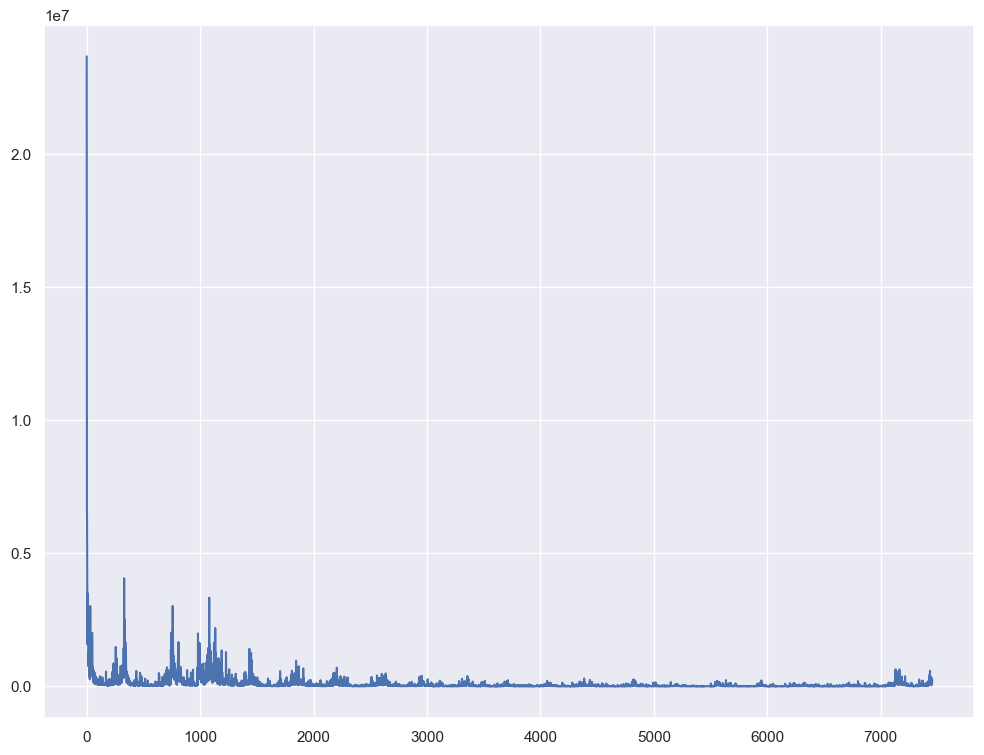

In [64]:
sns.lineplot(data = np.array([i["volume"] for i in data]))

<Axes: >

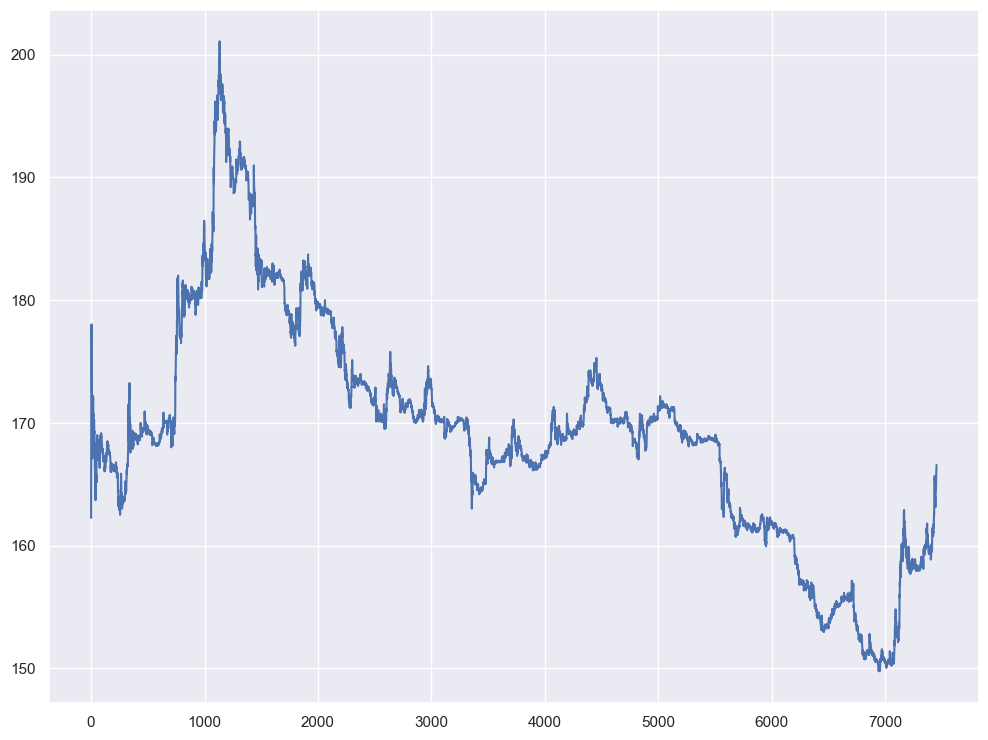

In [65]:
sns.lineplot(data = np.array([i["open"] for i in data]))

<Axes: >

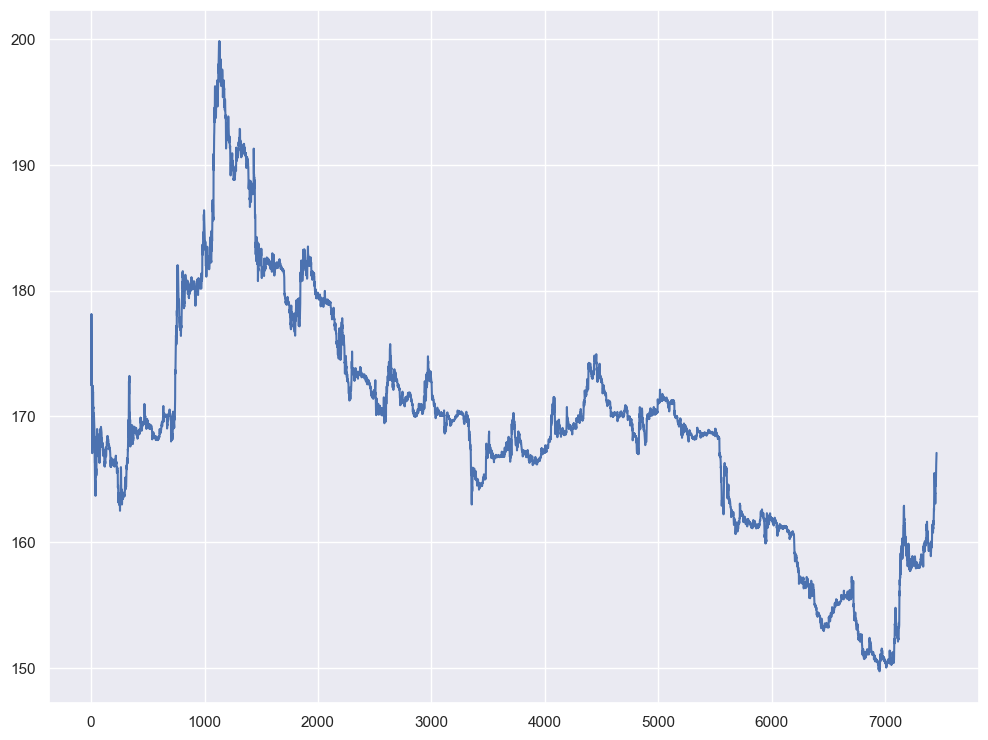

In [66]:
sns.lineplot(data = np.array([i["close"] for i in data]))

In [70]:
combine_price = np.zeros(len(data)*2)

In [71]:
combine_price[::2] = np.array([i["open"] for i in data])

In [77]:
combine_price[1::2] = np.array([i["close"] for i in data])

In [93]:
open_prices = np.array([i["open"] for i in data])
close_prices = np.array([i["close"] for i in data])
volume = np.array([i["volume"] for i in data])

<Axes: >

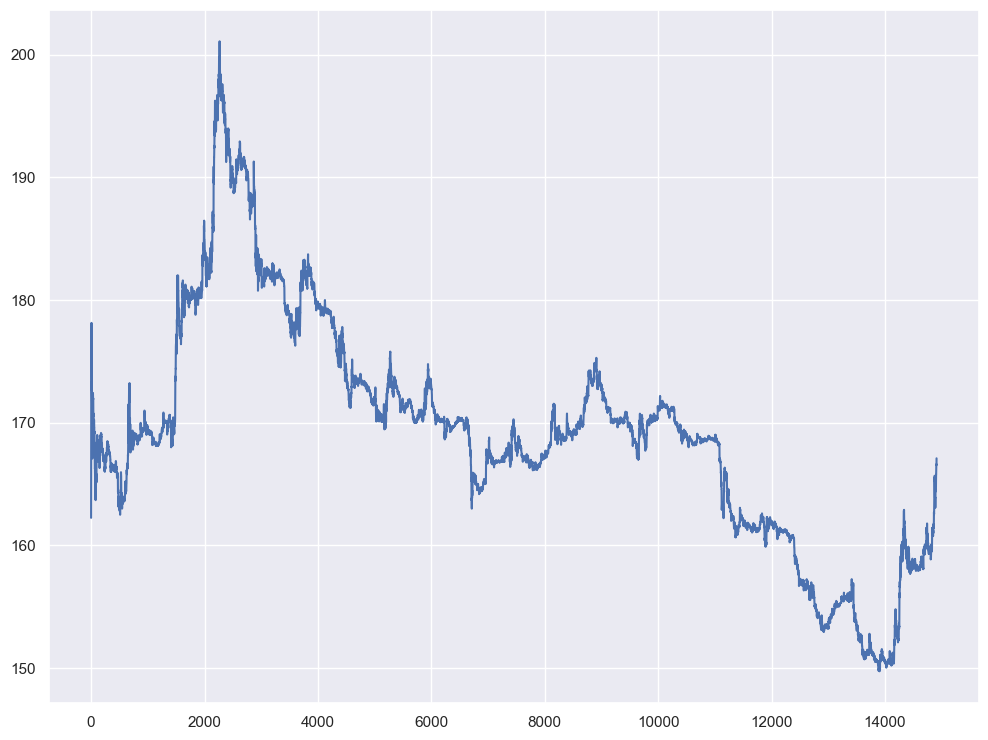

In [99]:
sns.lineplot(data = combine_price)

<Axes: >

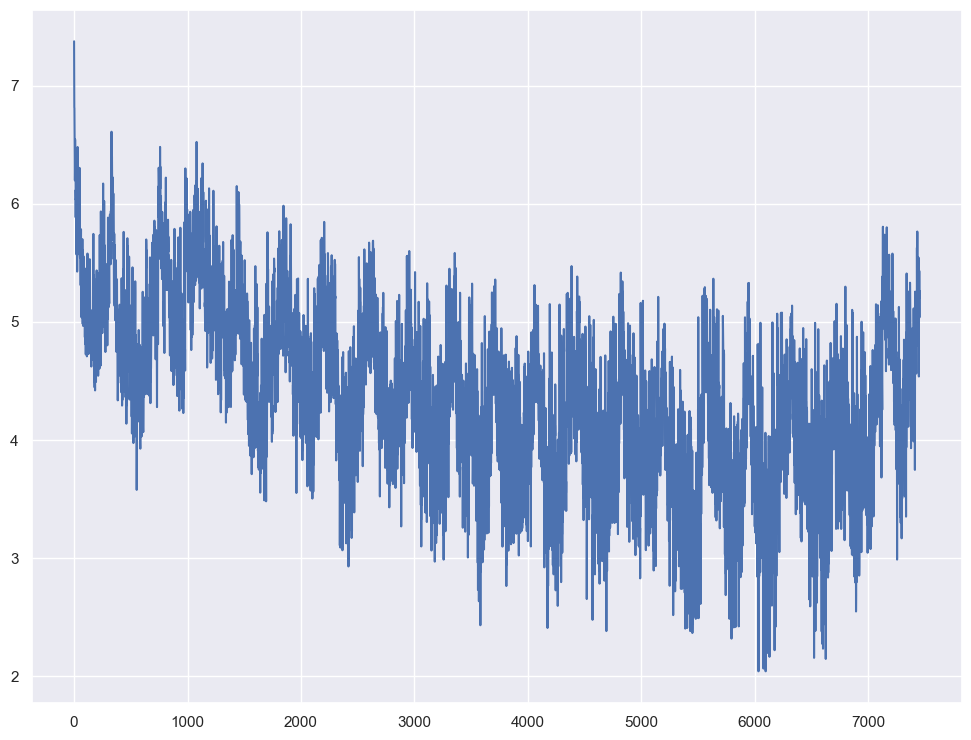

In [104]:
sns.lineplot(data = np.log10(volume))

<Axes: >

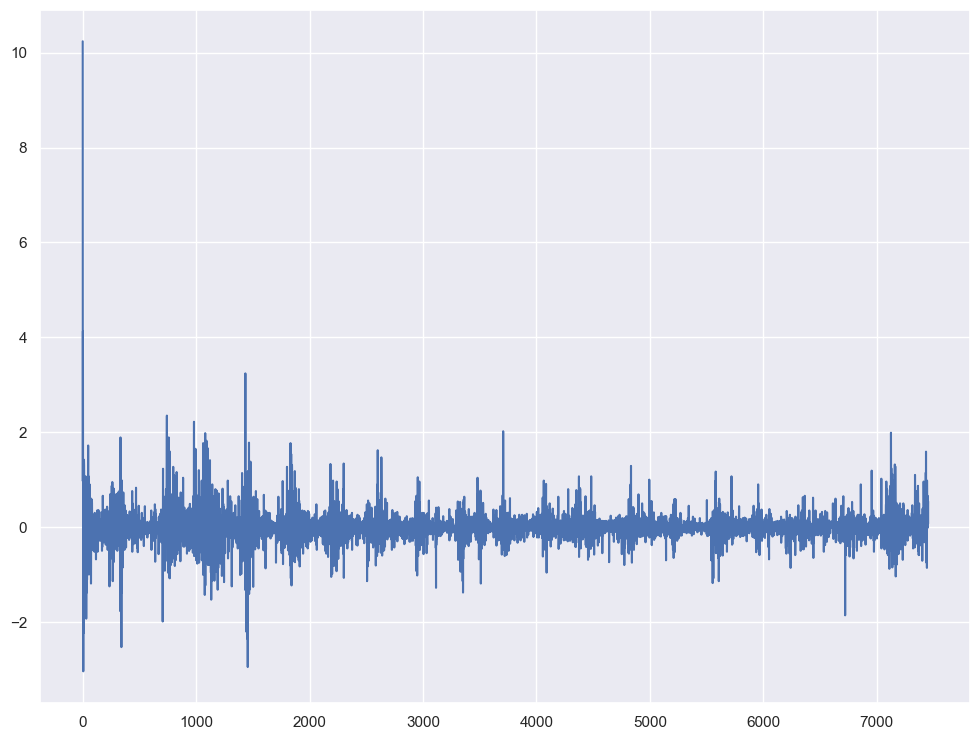

In [91]:
sns.lineplot(data = close_prices - open_prices)

In [109]:
volume[100:].argmax()

np.int64(230)

In [110]:
open_prices[100:].argmax()

np.int64(1033)

In [111]:
volume[100:][230]

np.int64(4064047)

In [112]:
volume[100:][1033]

np.int64(2192378)

In [113]:
open_prices[100:][1033]

np.float64(201.09)

Text(0.5, 1.0, ' sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak sarthak')

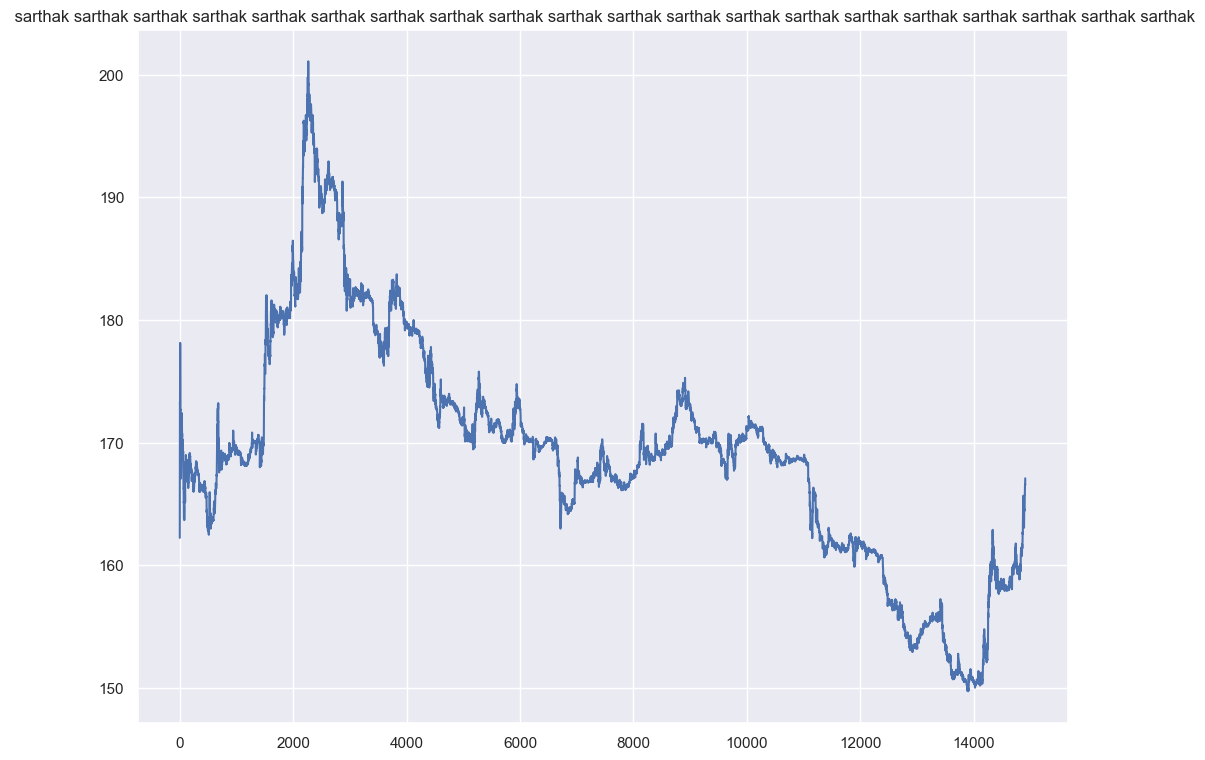

In [119]:
plt.plot(combine_price)
plt.title(" sarthak"*20)